#Assignment 3
Use the code from Chapter 6 in Natural Language Processing with Transformers and examine whether using few-shot prompting improves the ROUGE scores of the T5 model on the first article from the "cnn_dailymail" dataset. Add 1-4 examples from the training dataset to the prompt fed to T5 and plot the ROUGE scores as a function of the number of training examples added. Why does / doesn't the performance improve? Attach your Jupyter notebook as an appendix.


In [ ]:
%%capture
!pip install --upgrade datasets
!pip install --upgrade accelerate
!pip install --upgrade nltk
!pip install --upgrade rouge-score
!pip install --upgrade evaluate

In [ ]:
# hide
from transformers import pipeline, set_seed

## The CNN/DailyMail Dataset

In [ ]:
#hide_output
set_seed(42)
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")
print(f"Features: {dataset['train'].column_names}")

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Features: ['article', 'highlights', 'id']


In [ ]:
sample = dataset["train"][0]

print(f"""
Article (excerpt of 500 characters, total length: {len(sample["article"])}):
""")

print(sample["article"][:500])
print(f'\nSummary (length: {len(sample["highlights"])}):')
print(sample["highlights"])


Article (excerpt of 500 characters, total length: 2527):

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s

Summary (length: 217):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


## Text Summarization Pipelines

In [ ]:
sample_text = dataset["train"][0]["article"][:2000]
# We'll collect the generated summaries of each model in a dictionary
summaries = {}

In [ ]:
#hide_output
import nltk
from nltk.tokenize import sent_tokenize

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
string = "The U.S. are a country. The U.N. is an organization."
sent_tokenize(string)

['The U.S. are a country.', 'The U.N. is an organization.']

### Summarization Baseline


In [ ]:
def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])

In [ ]:
summaries["baseline"] = three_sentence_summary(sample_text)

#T5

In [ ]:
#hide_output
import torch

# Check if GPU is available, set device accordingly
device = 0 if torch.cuda.is_available() else -1

pipe = pipeline("summarization", model="t5-large", device=device)
pipe_out = pipe(sample_text)
summaries["t5"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


#Comparison

In [ ]:
print("GROUND TRUTH")
print(dataset["train"][0]["highlights"])
print("")

for model_name in summaries:
    print(model_name.upper())
    print(summaries[model_name])
    print("")

GROUND TRUTH
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .

BASELINE
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him.
Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties.
"I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month.

T5
Harry Potter star Daniel Radcliffe turns 18 on monday .
the young actor says he has no plans to fritt

### ROUGE

In [ ]:
# hide_output
from evaluate import load

rouge_metric = load("rouge")

In [ ]:
import pandas as pd

reference = dataset["train"][0]["highlights"]
records = []
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

for model_name in summaries:
    rouge_metric.add(prediction=summaries[model_name], reference=reference)
    score = rouge_metric.compute()
    rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
    records.append(rouge_dict)
pd.DataFrame.from_records(records, index=summaries.keys())

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.335484,0.248366,0.296774,0.335484
t5,0.575342,0.450704,0.547945,0.575342



## Few-Shot Prompting with T5 Model on CNN/DailyMail Dataset
Using the CNN/DailyMail dataset and applying few-shot prompting using 1 to 4 examples from the training set. Also calculate the ROUGE scores to evaluate performance based on the number of examples.
    

In [ ]:
!pip install ace-tools # Install the correct package
from IPython.display import display, Markdown
import pandas as pd

# Create a dataframe to store the ROUGE scores
rouge_df = pd.DataFrame({
    "Number of Examples": range(1, 5),
    "ROUGE-1": rouge_scores["rouge1"],
    "ROUGE-2": rouge_scores["rouge2"],
    "ROUGE-L": rouge_scores["rougeL"],
    "ROUGE-Lsum": rouge_scores["rougeLsum"]
})

# Display the dataframe using display from IPython.display
display(rouge_df) # Using the IPython display to render the DataFrame

,Number of Examples,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,1,0.095238,0.000000,0.057143,0.076190
1,2,0.067416,0.000000,0.044944,0.044944
2,3,0.141593,0.018018,0.088496,0.106195
3,4,0.129630,0.018868,0.092593,0.111111


Number of examples: 1

Example 1:
Text: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on

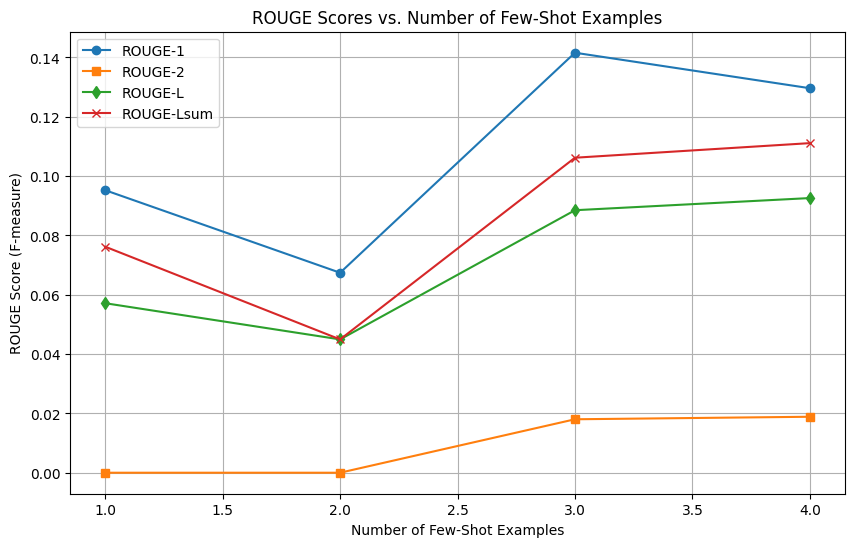

In [ ]:
import matplotlib.pyplot as plt

# Function to create few-shot prompt and print examples
def create_few_shot_prompt(article, examples, num_examples):
    prompt = "Summarize the following texts:\n\n"  # Base prompt
    print(f"Number of examples: {num_examples}\n")
    for i in range(num_examples):
        example_article, example_summary = examples[i]
        prompt += f"Text: {example_article}\nSummary: {example_summary}\n\n"
        print(f"Example {i + 1}:\nText: {example_article}\nSummary: {example_summary}\n")
    prompt += f"Text: {article}\nSummary:"  # Add the target article
    return prompt

# Get first article and summary from the test set
first_article = dataset["test"][0]["article"]
reference_summary = dataset["test"][0]["highlights"]

# Get few-shot examples from the training set
examples = [(dataset["train"][i]["article"], dataset["train"][i]["highlights"]) for i in range(4)]

# Dictionary to store ROUGE scores for each metric
rouge_scores = {
    "rouge1": [],
    "rouge2": [],
    "rougeL": [],
    "rougeLsum": []
}

    # Loop through 1 to 4 examples
for num_examples in range(1, 5):
    # Create few-shot prompt
    few_shot_prompt = create_few_shot_prompt(first_article, examples, num_examples)

    # Generate summary using T5
    generated_summary = pipe(few_shot_prompt)[0]["summary_text"]

    # Calculate ROUGE scores
    rouge_output = rouge_metric.compute(predictions=[generated_summary], references=[reference_summary])

    # Append all ROUGE scores - modified to directly access the metric values
    rouge_scores["rouge1"].append(rouge_output["rouge1"])  # Directly access the score
    rouge_scores["rouge2"].append(rouge_output["rouge2"])  # Directly access the score
    rouge_scores["rougeL"].append(rouge_output["rougeL"])  # Directly access the score
    rouge_scores["rougeLsum"].append(rouge_output["rougeLsum"]) # Directly access the score

# Plot the ROUGE scores as a function of the number of few-shot examples
plt.figure(figsize=(10, 6))
plt.plot(range(1, 5), rouge_scores["rouge1"], marker="o", label="ROUGE-1")
plt.plot(range(1, 5), rouge_scores["rouge2"], marker="s", label="ROUGE-2")
plt.plot(range(1, 5), rouge_scores["rougeL"], marker="d", label="ROUGE-L")
plt.plot(range(1, 5), rouge_scores["rougeLsum"], marker="x", label="ROUGE-Lsum")

plt.xlabel("Number of Few-Shot Examples")
plt.ylabel("ROUGE Score (F-measure)")
plt.title("ROUGE Scores vs. Number of Few-Shot Examples")
plt.legend()
plt.grid(True)
plt.show()
